Using SemEval 2020 Task 11 evaluation critique to measure how well our benchmark performs. Our methods/techniques compared to those used by others in the competition:

#### Subtask 1: Span Identification (SI)

| Category | Our System                          | Rank 1 (Team Hitachi)                      | Rank 2 (Team ApplicaAI)                   | Bottom Tier (e.g., Team WMD)                   |
| :--- |:------------------------------------|:-------------------------------------------|:------------------------------------------|:-----------------------------------------------|
| **Transformers** | RoBERTa (Base)                      | BERT, RoBERTa, XLNet, XLM, GPT-2           | RoBERTa                                   | BERT                                           |
| **Learning Models** | Token Classification Head           | Bi-LSTM, CRF                               | CRF                                       | Linear Head                                    |
| **Representations** | Transformer Embeddings              | Embeddings, PoS Tags, Named Entities (NEs) | Transformer Embeddings                    | Transformer Embeddings                         |
| **Misc. Techniques** | Ensemble (Cascade), Data Resampling | Ensemble                                   | Ensemble, Data Augmentation (Silver Data) | Ensemble, Data Augmentation (Back-translation) |
| **Best F1 Test Performance** | **53.76**                           | **51.55**                                  | **49.15**                                 | **0.3-37**                                     |

<br>

#### Subtask 2: Technique Classification (TC)

| Category                     | Our System                    | Rank 1 (Team ApplicaAI)                   | Rank 2 (Team aschern)                                       | Bottom Tier (Baselines)             |
|:-----------------------------|:------------------------------|:------------------------------------------|:------------------------------------------------------------|:------------------------------------|
| **Transformers**             | RoBERTa (Base)                | RoBERTa                                   | RoBERTa                                                     | *None (Traditional ML)*             |
| **Learning Models**          | Sequence Classification Head  | Linear Head                               | Linear Head                                                 | SVM / Logistic Regression           |
| **Representations**          | Positional Markers (`[SPAN]`) | Transformer Embeddings                    | Transformer Embeddings                                      | TF-IDF, Word/Char n-grams, Lexicons |
| **Misc. Techniques**         | Label Smoothing               | Ensemble, Data Augmentation (Silver Data) | Ensemble, Transfer Learning (from SI task), Post-processing | *None*                              |
| **Best F1 Test Performance** | **68.39**                     | **62.07**                                 | **62.01**                                                   | **19-40**                           |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import torch
import torch.nn.functional as F
import zipfile
import shutil
import gdown
from pathlib import Path
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    AutoModelForSequenceClassification,
)
from sklearn.metrics import classification_report

In [2]:
# Identify base directory to ensure portability
BASE_DIR = Path.cwd().resolve().parent
MODELS_DIR = BASE_DIR / "models"
DATA_PATH = BASE_DIR / "data" / "processed" / "semeval_tc_cleaned.csv"

SI_DIR = MODELS_DIR / "semeval_roberta_scanner"
SI_SPEC_DIR = MODELS_DIR / "semeval_roberta_scanner_specialist"
TC_DIR = MODELS_DIR / "semeval_roberta_classifier"

SI_MODEL_PATH = f"{os.fspath(SI_DIR.absolute())}"
SI_SPEC_PATH = f"{os.fspath(SI_SPEC_DIR.absolute())}"
TC_MODEL_PATH = f"{os.fspath(TC_DIR.absolute())}"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
test_df = pd.read_csv(DATA_PATH)
# Drop duplicate articles
articles_df = test_df[["article_id", "text_content"]].drop_duplicates(
    subset=["article_id"]
)

exclude = [
    "article_id",
    "text_content",
    "span_text",
    "sentiment",
    "punct_count",
    "lexical_diversity",
    "start",
    "end",
]
label_cols = [c for c in test_df.columns if c not in exclude]
print(f"Loaded test dataset with {len(test_df)} spans.")

Loaded test dataset with 7587 spans.


In [4]:
# Run training notebooks if models are missing
REQUIRED_FILES = ["config.json", "model.safetensors"]


def model_exists(path):
    path = Path(path)
    has_weights = any(path.glob("*.bin")) or any(path.glob("*.safetensors"))
    return has_weights


if not model_exists(SI_MODEL_PATH):
    print("SI Model missing. Running training notebook...")
    %run 4.1-fp-semeval-si-modeling.ipynb
if not model_exists(TC_MODEL_PATH):
    print("TC Model missing. Running training notebook...")
    %run 4.2-fp-semeval-tc-modeling.ipynb

In [5]:
def get_si_metrics(predicted_spans, gold_spans):
    if not predicted_spans and not gold_spans:
        return 1.0, 1.0, 1.0
    if not predicted_spans or not gold_spans:
        return 0.0, 0.0, 0.0

    # Precision
    p_num = 0
    for s in predicted_spans:
        max_overlap = 0
        for t in gold_spans:
            intersect = max(0, min(s[1], t[1]) - max(s[0], t[0]))
            max_overlap = max(max_overlap, intersect / (s[1] - s[0]))
        p_num += max_overlap
    precision = p_num / len(predicted_spans)

    # Recall
    r_num = 0
    for t in gold_spans:
        max_overlap = 0
        for s in predicted_spans:
            intersect = max(0, min(s[1], t[1]) - max(s[0], t[0]))
            max_overlap = max(max_overlap, intersect / (t[1] - t[0]))
        r_num += max_overlap
    recall = r_num / len(gold_spans)

    f1 = (
        2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    )
    return precision, recall, f1

In [6]:
# Load Base SI Model (RoBERTa token-classifier for span detection)
print(f"Loading Base SI Model from: {SI_MODEL_PATH}...")
si_tokenizer = AutoTokenizer.from_pretrained(SI_MODEL_PATH)
si_model = AutoModelForTokenClassification.from_pretrained(
    SI_MODEL_PATH, local_files_only=True
).to(device)
si_model.eval()

# Load Specialist SI Model
print(f"Loading Specialist SI Model from: {SI_SPEC_PATH}...")
si_spec_model = AutoModelForTokenClassification.from_pretrained(
    SI_SPEC_PATH, local_files_only=True
).to(device)
si_spec_model.eval()

Loading Base SI Model from: /Users/frankiepike/MADS_Projects/Claim-Aware_Propaganda_Scanner/models/semeval_roberta_scanner...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading Specialist SI Model from: /Users/frankiepike/MADS_Projects/Claim-Aware_Propaganda_Scanner/models/semeval_roberta_scanner_specialist...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForTokenClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (L

In [7]:
# Load TC Model (Technique Classification)
tc_tokenizer = AutoTokenizer.from_pretrained("roberta-base")
tc_model = AutoModelForSequenceClassification.from_pretrained(TC_MODEL_PATH).to(device)
tc_model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50267, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.2, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [8]:
# Set thresholds for each technique
OPTIMIZED_THRESHOLDS = {
    "Appeal_to_Authority": 0.60,
    "Appeal_to_fear-prejudice": 0.50,
    "Bandwagon_Reductio_ad_hitlerum": 0.10,
    "Black-and-White_Fallacy": 0.20,
    "Causal_Oversimplification": 0.20,
    "Doubt": 0.35,
    "Exaggeration_Minimisation": 0.40,
    "Flag-Waving": 0.45,
    "Loaded_Language": 0.40,
    "Name_Calling_Labeling": 0.55,
    "Repetition": 0.40,
    "Slogans": 0.30,
    "Thought-terminating_Cliches": 0.15,
    "Whataboutism_Straw_Men_Red_Herring": 0.15,
}

In [9]:
def run_pipeline(text):
    # Identify spans
    inputs = si_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        return_offsets_mapping=True,
    ).to(device)
    offsets = inputs.pop("offset_mapping")[0]

    with torch.no_grad():
        # Get Base Model Predictions (3 classes: 0, 1, 2)
        base_outputs = si_model(**inputs)
        base_logits = base_outputs.logits
        base_preds = torch.argmax(base_logits, dim=-1)[0]

        # Get Specialist Model Predictions (2 classes: 0, 1)
        spec_outputs = si_spec_model(**inputs)
        spec_logits = spec_outputs.logits

        # Calculate Specialist Confidence (Softmax)
        spec_probs = F.softmax(spec_logits, dim=-1)[0]
        propaganda_prob = spec_probs[:, 1]

    # Initialize final predictions with base model's results
    final_preds = base_preds.clone()

    # CASCADE LOGIC: If base found nothing (0) AND specialist is confident (> threshold)
    # We set it to '1' (which is the 'Beginning' tag in the base model)
    mask = (base_preds == 0) & (propaganda_prob > 0.5)
    final_preds[mask] = 1

    # Extract spans from the combined predictions
    predicted_spans = []
    current_span = None

    for i, pred in enumerate(final_preds):
        label = pred.item()
        start, end = offsets[i]
        if start == end:
            continue

        # In BIO tagging: 1 is 'B' (Begin), 2 is 'I' (Inside)
        if label in [1, 2]:
            if current_span is None:
                current_span = [start.item(), end.item()]
            else:
                current_span[1] = end.item()
        else:
            if current_span:
                predicted_spans.append(tuple(current_span))
                current_span = None

    if current_span:
        predicted_spans.append(tuple(current_span))

    # Technique classification
    final_results = []
    for span in predicted_spans:
        span_text = text[span[0] : span[1]].strip()
        if not span_text:
            continue

        tc_inputs = tc_tokenizer(
            span_text, return_tensors="pt", truncation=True, padding=True
        ).to(device)

        with torch.no_grad():
            tc_logits = tc_model(**tc_inputs).logits
            probs = torch.sigmoid(tc_logits)[0]  # Convert logits to probabilities

        # Find all techniques that pass their specific optimized threshold
        found_techniques = []
        for class_id, prob in enumerate(probs):
            tech_name = tc_model.config.id2label[class_id]
            threshold = OPTIMIZED_THRESHOLDS.get(
                tech_name, 0.5
            )  # Default to 0.5 just in case

            if prob.item() >= threshold:
                found_techniques.append(tech_name)

        # Fallback: if the model is so unsure that NOTHING passes, just pick the single most likely one
        if not found_techniques:
            best_class = torch.argmax(probs).item()
            found_techniques.append(tc_model.config.id2label[best_class])

        # Add all passing techniques to the final results
        for tech in found_techniques:
            final_results.append({"span": tuple(span), "technique": tech})

    return final_results

Tracking performance

--3/17 8:12 PM: SI F1: 0.2175, Pipeline TC F1: 0.0790 (prioritizing recall in T1 and precision in T2)

--3/17 8:40 PM: SI F1: 0.4117, Pipeline TC F1: 0.3173 (still the old architecture for SI but prioritizing F1)

--3/18 2:15 PM: SI F1: 0.5121, Pipeline TC F1: 0.4788 (prioritizing F1, training more)

--3/20: 1:44 PM: SI F1: 0.5202, Pipeline TC F1: 0.4944 (adding cascade logic)

--4/3: 11:23 PM: SI F1: 0.5202, Pipeline TC F1: 0.6839 (added smoothing, shrunk to 14 labels)

In [10]:
# Evaluating strict TC on gold spans for Radar Chart (SemEval Subtask TC Standard)

true_labels = []
pred_labels = []

# 1. Run quick predictions strictly on gold spans
for _, g_row in test_df.iterrows():
    techs = [col for col in label_cols if g_row[col] == 1]
    if not techs:
        continue
    true_tech = techs[0].replace("_", " ").lower()
    true_labels.append(true_tech)

    span_text = str(g_row["span_text"])
    tc_inputs = tc_tokenizer(
        span_text, return_tensors="pt", truncation=True, padding=True
    ).to(device)
    with torch.no_grad():
        tc_logits = tc_model(**tc_inputs).logits
        pred_class = torch.argmax(tc_logits, dim=1).item()

    pred_tech = tc_model.config.id2label[pred_class].replace("_", " ").lower()
    pred_labels.append(pred_tech)

In [11]:
# 2. Extract Per-Technique F1 Scores automatically via sklearn (For the Pipeline)
report = classification_report(
    true_labels, pred_labels, output_dict=True, zero_division=0
)

# 3. Map our dynamically generated Pipeline scores
pipeline_scores = {
    "Loaded Language": report.get("loaded language", {}).get("f1-score", 0) * 100,
    "Name Calling, Labeling": report.get("name calling labeling", {}).get("f1-score", 0)
    * 100,
    "Repetition": report.get("repetition", {}).get("f1-score", 0) * 100,
    "Exaggeration, Minimisation": report.get("exaggeration minimisation", {}).get(
        "f1-score", 0
    )
    * 100,
    "Doubt": report.get("doubt", {}).get("f1-score", 0) * 100,
    "Appeal to fear/prejudice": report.get("appeal to fear-prejudice", {}).get(
        "f1-score", 0
    )
    * 100,
    "Flag-waving": report.get("flag-waving", {}).get("f1-score", 0) * 100,
    "Causal Oversimplification": report.get("causal oversimplification", {}).get(
        "f1-score", 0
    )
    * 100,
    "Slogans": report.get("slogans", {}).get("f1-score", 0) * 100,
    "Appeal to authority": report.get("appeal to authority", {}).get("f1-score", 0)
    * 100,
    "Black-and-white Fallacy": report.get("black-and-white fallacy", {}).get(
        "f1-score", 0
    )
    * 100,
    "Thought-terminating cliché": report.get("thought-terminating cliches", {}).get(
        "f1-score", 0
    )
    * 100,
    "Whataboutism, Straw Men, Red Herring": report.get(
        "whataboutism straw men red herring", {}
    ).get("f1-score", 0)
    * 100,
    "Bandwagon": report.get("bandwagon reductio ad hitlerum", {}).get("f1-score", 0)
    * 100,
}

# 4. Map our Notebook 4.2 isolated scores (Apples-to-Apples with competition)
isolated_tc_scores = {
    "Loaded Language": 82.17,
    "Name Calling, Labeling": 81.65,
    "Repetition": 57.97,
    "Exaggeration, Minimisation": 49.75,
    "Doubt": 68.72,
    "Appeal to fear/prejudice": 61.16,
    "Flag-waving": 71.76,
    "Causal Oversimplification": 48.00,
    "Slogans": 53.33,
    "Appeal to authority": 50.00,
    "Black-and-white Fallacy": 46.15,
    "Thought-terminating cliché": 24.49,
    "Whataboutism, Straw Men, Red Herring": 20.00,
    "Bandwagon": 19.15,
}

# 5. Create DataFrame and map to SemEval 2020 Table 6 Results
semeval_competitors = {
    "Loaded Language": {
        "ApplicaAI's TC Model": 77.12,
        "aschern's TC Model": 77.02,
        "Hitachi's TC Model": 75.64,
        "NLFIIT (Median)'s TC Model": 72.55,
    },
    "Name Calling, Labeling": {
        "ApplicaAI's TC Model": 74.38,
        "aschern's TC Model": 75.65,
        "Hitachi's TC Model": 74.20,
        "NLFIIT (Median)'s TC Model": 69.30,
    },
    "Repetition": {
        "ApplicaAI's TC Model": 54.55,
        "aschern's TC Model": 53.38,
        "Hitachi's TC Model": 37.88,
        "NLFIIT (Median)'s TC Model": 21.55,
    },
    "Exaggeration, Minimisation": {
        "ApplicaAI's TC Model": 33.59,
        "aschern's TC Model": 32.65,
        "Hitachi's TC Model": 34.58,
        "NLFIIT (Median)'s TC Model": 30.30,
    },
    "Doubt": {
        "ApplicaAI's TC Model": 56.23,
        "aschern's TC Model": 59.44,
        "Hitachi's TC Model": 63.43,
        "NLFIIT (Median)'s TC Model": 55.66,
    },
    "Appeal to fear/prejudice": {
        "ApplicaAI's TC Model": 45.49,
        "aschern's TC Model": 41.78,
        "Hitachi's TC Model": 38.94,
        "NLFIIT (Median)'s TC Model": 24.89,
    },
    "Flag-waving": {
        "ApplicaAI's TC Model": 69.43,
        "aschern's TC Model": 66.35,
        "Hitachi's TC Model": 68.02,
        "NLFIIT (Median)'s TC Model": 63.32,
    },
    "Causal Oversimplification": {
        "ApplicaAI's TC Model": 22.73,
        "aschern's TC Model": 25.97,
        "Hitachi's TC Model": 36.62,
        "NLFIIT (Median)'s TC Model": 0.00,
    },
    "Slogans": {
        "ApplicaAI's TC Model": 51.28,
        "aschern's TC Model": 54.24,
        "Hitachi's TC Model": 45.61,
        "NLFIIT (Median)'s TC Model": 41.67,
    },
    "Appeal to authority": {
        "ApplicaAI's TC Model": 48.15,
        "aschern's TC Model": 35.29,
        "Hitachi's TC Model": 40.00,
        "NLFIIT (Median)'s TC Model": 29.63,
    },
    "Black-and-white Fallacy": {
        "ApplicaAI's TC Model": 49.02,
        "aschern's TC Model": 53.57,
        "Hitachi's TC Model": 47.92,
        "NLFIIT (Median)'s TC Model": 32.10,
    },
    "Thought-terminating cliché": {
        "ApplicaAI's TC Model": 39.22,
        "aschern's TC Model": 42.55,
        "Hitachi's TC Model": 29.41,
        "NLFIIT (Median)'s TC Model": 13.64,
    },
    "Whataboutism, Straw Men, Red Herring": {
        "ApplicaAI's TC Model": 25.00,
        "aschern's TC Model": 18.87,
        "Hitachi's TC Model": 26.92,
        "NLFIIT (Median)'s TC Model": 0.00,
    },
    "Bandwagon": {
        "ApplicaAI's TC Model": 8.33,
        "aschern's TC Model": 14.93,
        "Hitachi's TC Model": 4.88,
        "NLFIIT (Median)'s TC Model": 9.30,
    },
}

df_comparison = pd.DataFrame(semeval_competitors).T

In [12]:
# 6. Insert both columns into the dataframe!
df_comparison.insert(
    0,
    "Our Complete Pipeline (Full Task F1)",
    [pipeline_scores.get(tech, 0.0) for tech in df_comparison.index],
)
df_comparison.insert(
    0,
    "Our TC Model (Subtask 2)",
    [isolated_tc_scores.get(tech, 0.0) for tech in df_comparison.index],
)

display(df_comparison)

,Our TC Model (Subtask 2),Our Complete Pipeline (Full Task F1),ApplicaAI's TC Model,aschern's TC Model,Hitachi's TC Model,NLFIIT (Median)'s TC Model
Loaded Language,82.17,7.528345,77.12,77.02,75.64,72.55
"Name Calling, Labeling",81.65,43.009226,74.38,75.65,74.20,69.30
Repetition,57.97,0.317965,54.55,53.38,37.88,21.55
"Exaggeration, Minimisation",49.75,29.503106,33.59,32.65,34.58,30.30
Doubt,68.72,46.631517,56.23,59.44,63.43,55.66
Appeal to fear/prejudice,61.16,42.841037,45.49,41.78,38.94,24.89
Flag-waving,71.76,15.347913,69.43,66.35,68.02,63.32
Causal Oversimplification,48.00,42.962963,22.73,25.97,36.62,0.00
Slogans,53.33,8.275862,51.28,54.24,45.61,41.67
Appeal to authority,50.00,15.512927,48.15,35.29,40.00,29.63


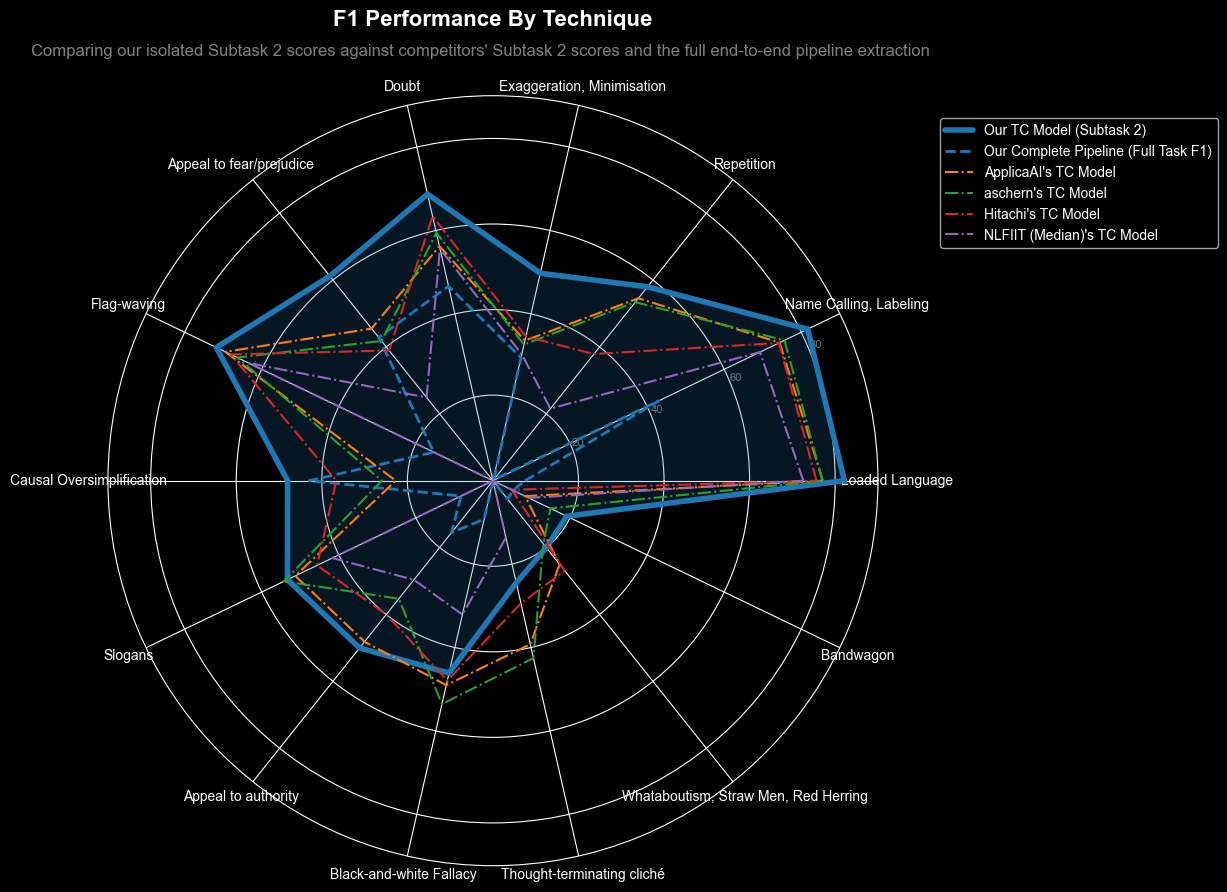

In [13]:
# Prepare data for radar chart
categories = df_comparison.index.tolist()
N = len(categories)
file_name = BASE_DIR / "reports/figures/radar_chart_comparison.png"

# Determine the angles for each technique radially
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

teams = df_comparison.columns

# Map styles: Both of 'Our' models are blue, but styled differently.
styles = {
    "Our TC Model (Subtask 2)": {"color": "#1f77b4", "lw": 4, "ls": "-", "fill": True},
    "Our Complete Pipeline (Full Task F1)": {
        "color": "#1f77b4",
        "lw": 2,
        "ls": "--",
        "fill": False,
    },
    "ApplicaAI's TC Model": {"color": "#ff7f0e", "lw": 1.5, "ls": "-.", "fill": False},
    "aschern's TC Model": {"color": "#2ca02c", "lw": 1.5, "ls": "-.", "fill": False},
    "Hitachi's TC Model": {"color": "#d62728", "lw": 1.5, "ls": "-.", "fill": False},
    "NLFIIT (Median)'s TC Model": {
        "color": "#9467bd",
        "lw": 1.5,
        "ls": "-.",
        "fill": False,
    },
}

for team in teams:
    values = df_comparison[team].tolist()
    values += values[:1]  # close the circle

    # Get style for this team
    st = styles.get(team, {"color": "gray", "lw": 1.5, "ls": "-", "fill": False})

    ax.plot(
        angles,
        values,
        color=st["color"],
        linewidth=st["lw"],
        linestyle=st["ls"],
        label=team,
    )

    # Only fill the main TC model
    if st["fill"]:
        ax.fill(angles, values, color=st["color"], alpha=0.20)

# Apply formatting
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10, wrap=True)
ax.set_ylim(0, 90)
ax.set_yticks([20, 40, 60, 80])
ax.set_yticklabels(["20", "40", "60", "80"], color="grey", size=8)

plt.title("F1 Performance By Technique", size=16, weight="bold", y=1.08)
plt.figtext(
    0.5,
    0.92,
    "Comparing our isolated Subtask 2 scores against competitors' Subtask 2 scores and the full end-to-end pipeline extraction",
    ha="center",
    fontsize=12,
    color="gray",
)
plt.legend(loc="upper right", bbox_to_anchor=(1.45, 0.98))

plt.savefig(file_name, bbox_inches="tight")
plt.show()

In [14]:
# Scoring
TOLERANCE = 10  # Forgive span boundaries off by this many characters
PARTIAL_CREDIT = 0.5  # Credit for finding propaganda, but wrong technique
FULL_CREDIT = 1.0  # Credit for right span AND right technique

global_custom_p_num, global_custom_p_den = 0, 0
global_custom_r_num, global_custom_r_den = 0, 0

print(f"Evaluating Realistic Pipeline on {test_df['article_id'].nunique()} articles...")

# Save the results for later
pipeline_results = []

for _, row in articles_df.iterrows():
    article_id = row["article_id"]
    full_text = row["text_content"]

    # 1. Get gold labels
    gold_rows = test_df[test_df["article_id"] == article_id]
    gold_data = []
    for _, g_row in gold_rows.iterrows():
        techs = [col for col in label_cols if g_row[col] == 1]
        if "start" in g_row and pd.notna(g_row["start"]):
            s, e = int(g_row["start"]), int(g_row["end"])
        else:
            s = full_text.find(str(g_row["span_text"]))
            e = s + len(str(g_row["span_text"]))

        if s != -1:
            for t in techs:
                gold_data.append({"span": (s, e), "tech": t})

    # 2. Run predictions and save for later
    predictions = run_pipeline(full_text)
    predicted_spans = [p["span"] for p in predictions]
    pipeline_results.append(
        {
            "article_id": article_id,
            "text": full_text,
            "predicted_spans": predicted_spans,
        }
    )

    # 3. Custom Precision: Did the model's predictions match reality?
    global_custom_p_den += len(predictions)
    for p in predictions:
        best_score = 0
        p_tech_clean = p["technique"].replace("_", " ").lower()

        for g in gold_data:
            g_tech_clean = g["tech"].replace("_", " ").lower()

            # Check boundaries against tolerance
            start_diff = abs(p["span"][0] - g["span"][0])
            end_diff = abs(p["span"][1] - g["span"][1])

            if start_diff <= TOLERANCE and end_diff <= TOLERANCE:
                if p_tech_clean == g_tech_clean:
                    best_score = max(best_score, FULL_CREDIT)
                else:
                    best_score = max(best_score, PARTIAL_CREDIT)

        global_custom_p_num += best_score

    # 4. Custom Recall: Did the model find the true gold spans?
    global_custom_r_den += len(gold_data)
    for g in gold_data:
        best_score = 0
        g_tech_clean = g["tech"].replace("_", " ").lower()

        for p in predictions:
            p_tech_clean = p["technique"].replace("_", " ").lower()

            start_diff = abs(p["span"][0] - g["span"][0])
            end_diff = abs(p["span"][1] - g["span"][1])

            if start_diff <= TOLERANCE and end_diff <= TOLERANCE:
                if p_tech_clean == g_tech_clean:
                    best_score = max(best_score, FULL_CREDIT)
                else:
                    best_score = max(best_score, PARTIAL_CREDIT)

        global_custom_r_num += best_score

Evaluating Realistic Pipeline on 357 articles...


In [16]:
# Save predictions
output_path = Path("../data/processed/pipeline_predictions.json").resolve()
with open(output_path, "w") as f:
    json.dump(pipeline_results, f)

print(f"Saved {len(pipeline_results)} pipeline predictions for analysis")

Saved 357 pipeline predictions for analysis


In [17]:
# Calculate Final Realistic Scores
custom_p = global_custom_p_num / global_custom_p_den if global_custom_p_den > 0 else 0
custom_r = global_custom_r_num / global_custom_r_den if global_custom_r_den > 0 else 0
custom_f1 = (
    (2 * custom_p * custom_r / (custom_p + custom_r))
    if (custom_p + custom_r) > 0
    else 0
)

print("\n" + "=" * 45)
print(f"Realistic Pipeline Precision: {custom_p:.4f}")
print(f"Realistic Pipeline Recall:    {custom_r:.4f}")
print(f"Realistic Pipeline F1 Score:  {custom_f1:.4f}")
print("=" * 45)


Realistic Pipeline Precision: 0.3223
Realistic Pipeline Recall:    0.1741
Realistic Pipeline F1 Score:  0.2261


Performance with old best TC model: Realistic Pipeline Precision: 0.3260
Realistic Pipeline Recall:    0.1609
Realistic Pipeline F1 Score:  0.2154

Performance with model down to 14 techniques, adding smoothing: Realistic Pipeline Precision: 0.3350
Realistic Pipeline Recall:    0.1765
Realistic Pipeline F1 Score:  0.2312